# 02 · Features ancladas en el origen, y la prueba de que no miran el futuro

Un README que dice «evité leakage» no prueba nada. Este notebook muestra el diseño que hace
la fuga **inexpresable**, y después corre los ocho asserts del checklist —cada uno con su
caso negativo, o sea inyectando la fuga a propósito y verificando que el assert la agarre.

Un test antifugas que pasa siempre, incluso con fuga presente, es peor que no tenerlo.

## El diseño primero, los tests después

El contrato de modelo (`src/blindside/models/base.py`) fija que un modelo recibe:

- `history`: el panel **hasta el origen**, nada después
- `future`: un índice de fechas objetivo **sin columna de target**

No tiene desde dónde mirar el futuro ni por accidente. La fuga deja de ser algo que hay que
recordar no hacer y pasa a ser algo que no se puede escribir.

In [1]:
import numpy as np
import pandas as pd

from blindside import config as cfg
from blindside.data import loaders
from blindside.data import schema as S
from blindside.features import build as fb
from blindside.models.base import FORBIDDEN_IN_FUTURE, FUTURE_INDEX_COLS
from blindside.validation import leakage as lk

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)

panel = loaders.load_demand()
print(f"panel: {len(panel):,} filas · {panel[S.SERIES_ID].nunique():,} series")
print(f"lo único que el índice de futuro debe traer: {FUTURE_INDEX_COLS}")
print(f"columnas prohibidas en el índice de futuro : {FORBIDDEN_IN_FUTURE}")
print(f"conocidas de antemano (sí permitidas)      : {S.KNOWN_FUTURE_COLS}")

# Submuestra declarada, con la semilla del proyecto. Los items 5 a 8 del checklist
# exigen ajustar un modelo por cada variante, y sobre las 3.066 series eso son
# minutos por celda. Lo que se verifica acá es el **pipeline**, no el tamaño del
# panel: las mismas funciones corren sobre el panel completo en `make models`.
rng = np.random.default_rng(cfg.SEED)
elegidas = set(rng.choice(sorted(panel[S.SERIES_ID].astype(str).unique()), 400, replace=False))
chico = panel[panel[S.SERIES_ID].astype(str).isin(elegidas)]
print(f"\nsubmuestra de trabajo: {len(chico):,} filas · {chico[S.SERIES_ID].nunique()} series")

panel: 297,402 filas · 3,066 series
lo único que el índice de futuro debe traer: ('series_id', 'dt', 'h')
columnas prohibidas en el índice de futuro : ('sale_amount', 'demand_latent', 'stock_hour6_22_cnt', 'oos_hours_day', 'available_weight', 'is_censored', 'inflation_factor')
conocidas de antemano (sí permitidas)      : ('discount', 'holiday_flag', 'activity_flag')

submuestra de trabajo: 38,800 filas · 400 series


## 1 · El estado de origen

`add_origin_features` calcula, **para cada fila del panel**, todo lo que se sabe al cerrar ese
día: lags, rolling, estacionales, intermitencia, historia de censura y exógenas rezagadas.

El punto de diseño: cualquier fila puede usarse como origen y sus features son válidas **por
construcción**, no por convención.

In [2]:
estado = fb.add_origin_features(chico, target=S.DEMAND_LATENT)
nuevas = [c for c in estado.columns if c not in chico.columns]
print(f"features de estado agregadas: {len(nuevas)}")

familias = {
    "lags": [c for c in nuevas if "_lag_" in c],
    "rolling": [c for c in nuevas if "_roll_" in c],
    "estacionales": [c for c in nuevas if "seasonal" in c or "dow" in c],
    "intermitencia": [c for c in nuevas if "zero" in c or "adi" in c or "cv2" in c],
    "censura": [c for c in nuevas if "censored" in c or "oos" in c],
}
for nombre, cols in familias.items():
    print(f"  {nombre:<15} {len(cols):>3}  p.ej. {cols[:3]}")
restantes = set(nuevas) - {c for cols in familias.values() for c in cols}
print(f"  {'otras':<15} {len(restantes):>3}  {sorted(restantes)[:5]}")

features de estado agregadas: 50
  lags             27  p.ej. ['latent_lag_0', 'latent_lag_1', 'latent_lag_2']
  rolling          16  p.ej. ['latent_roll_mean_7', 'latent_roll_std_7', 'latent_roll_max_7']
  estacionales      2  p.ej. ['latent_dow_mean_4', 'latent_dow_std_4']
  intermitencia     1  p.ej. ['zero_share_28']
  censura           3  p.ej. ['censored_share_7', 'censored_share_28', 'oos_hours_roll_7']
  otras             2  ['days_since_sale', 'latent_momentum_7_28']


## 2 · La matriz supervisada

`build_supervised` cruza el estado de cada origen con sus `horizon` días objetivo. Una fila por
`(serie, origen, h)`.

Del día objetivo se toma **solo** lo conocido de antemano, más la verdad y la venta observada,
que son etiquetas y no features.

In [3]:
origenes = fb.make_origins(
    chico, horizon=cfg.FORECAST.horizon, min_train_days=cfg.FORECAST.min_train_days
)
print(f"orígenes disponibles: {len(origenes)}  ({origenes[0].date()} → {origenes[-1].date()})")

# Siete orígenes con paso 3, igual que la suite de tests. Con menos de siete la
# partición de los items 6 y 7 queda tan fina que el resultado es ruido.
elegidos = origenes[-21::3][:7]
print(f"orígenes usados: {[str(d.date()) for d in elegidos]}")

sup = fb.build_supervised(estado, elegidos, horizon=cfg.FORECAST.horizon, target=S.DEMAND_LATENT)
features = fb.feature_columns(sup)
print(f"\nmatriz: {len(sup):,} filas × {len(features)} features")
print(f"pasos de horizonte: {sorted(sup[fb.H].unique())}")

orígenes disponibles: 49  (2024-05-08 → 2024-06-25)
orígenes usados: ['2024-06-05', '2024-06-08', '2024-06-11', '2024-06-14', '2024-06-17', '2024-06-20', '2024-06-23']

matriz: 19,600 filas × 73 features
pasos de horizonte: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7)]


### La propiedad que define «anclada en el origen»

Una feature legítima es **constante dentro de cada `(serie, origen)`**: describe el estado al
cerrar el origen, así que no puede cambiar según qué día se esté pronosticando.

Las únicas que pueden variar con `h` son las que se conocen de antemano: el calendario del día
objetivo, el propio `h`, y el plan comercial.

In [4]:
from blindside.features.calendar import CALENDAR_FEATURES

permitido_variar = {fb.H, *CALENDAR_FEATURES, *S.KNOWN_FUTURE_COLS, "days_to_holiday", "is_holiday"}
grupos = sup.groupby([S.SERIES_ID, fb.ORIGIN_DATE], observed=True)

varian = [c for c in features if c not in permitido_variar and grupos[c].nunique(dropna=False).max() > 1]
constantes = [c for c in features if c not in permitido_variar and c not in varian]

print(f"features que DEBEN ser constantes por (serie, origen): {len(constantes)}")
print(f"features que varían y no deberían                    : {len(varian)}  {varian}")
print(f"features que pueden variar por ser conocidas         : {sorted(set(features) & permitido_variar)}")

features que DEBEN ser constantes por (serie, origen): 57
features que varían y no deberían                    : 0  []
features que pueden variar por ser conocidas         : ['activity_flag', 'day_of_month', 'days_since_start', 'discount', 'dom_cos', 'dom_sin', 'dow', 'dow_cos', 'dow_sin', 'h', 'holiday_flag', 'is_month_end', 'is_month_start', 'is_weekend', 'month', 'week_of_year']


## 3 · Los ocho asserts, corriendo

Esto es `make test-leakage` desplegado. Cada bloque hace dos cosas: correr el assert sobre los
datos reales (tiene que pasar) y después **inyectar la fuga** y verificar que el assert la
detecte (tiene que fallar).

El segundo paso es el que le da valor al primero.

In [5]:
def verificar(nombre: str, positivo, negativo=None) -> None:
    """Corre el assert sobre datos limpios y, si se da, sobre datos con fuga."""
    try:
        positivo()
        print(f"[ok]      {nombre}: pasa sobre los datos reales")
    except lk.LeakageError as exc:
        print(f"[FUGA]    {nombre}: {exc}")
        return
    if negativo is None:
        return
    try:
        negativo()
        print(f"[INUTIL]  {nombre}: con la fuga inyectada NO falló — el assert no sirve")
    except lk.LeakageError:
        print(f"[ok]      {nombre}: detecta la fuga inyectada")

In [6]:
# Item 1 · Sin features posteriores a t.
# La fuga inyectada es un lag calculado respecto de la fecha OBJETIVO en vez del
# origen. Para un objetivo en T+7 eso vale y[T+6]: seis días dentro del futuro. Se
# detecta porque cambia dentro de un mismo (serie, origen), que es la forma que
# tiene la fuga en este diseño.
con_fuga = sup.copy()
con_fuga["lag1_desde_objetivo"] = con_fuga[fb.Y].shift(1).fillna(0.0)
assert "lag1_desde_objetivo" in fb.feature_columns(con_fuga), "la fuga no entró como feature"

verificar(
    "1 sin features del futuro",
    lambda: lk.assert_no_future_columns(sup),
    lambda: lk.assert_no_future_columns(con_fuga),
)

[ok]      1 sin features del futuro: pasa sobre los datos reales
[ok]      1 sin features del futuro: detecta la fuga inyectada


### La segunda barrera, que es estructural

El item 1 detecta la fuga **midiendo**: una feature que cambia dentro de un mismo
`(serie, origen)` depende de la fecha objetivo. Hay una barrera anterior que la descarta
**por patrón**, sin medir nada: nada que termine en `_target` entra a la matriz.

Ese sufijo lo pone pandas al unir el estado del origen con la verdad del día objetivo cuando
hay choque de nombres, así que una columna `algo_target` es **por definición** del día
objetivo. Es la barrera que atrapó el primer bug real de este proyecto, y la que hace que
agregar una columna nueva al panel no pueda abrir una fuga por olvidarse de declararla.

Dos barreras distintas, y conviene ver las dos funcionando: la de patrón no necesita datos y
la de medición agarra lo que el patrón no nombra.

In [7]:
estructural = sup.copy()
estructural["is_censored_target"] = True  # el bug real de este repo
estructural["cualquier_cosa_target"] = estructural[fb.Y]  # una copia literal del target

cols = fb.feature_columns(estructural)
colados = [c for c in cols if c.endswith("_target")]
print(f"columnas _target agregadas al frame : 2")
print(f"columnas _target que entran como feature: {len(colados)}  {colados}")
print("\nNi siquiera llegan al assert: `feature_columns` las filtra antes.")

columnas _target agregadas al frame : 2
columnas _target que entran como feature: 0  []

Ni siquiera llegan al assert: `feature_columns` las filtra antes.


In [8]:
# Item 2 · Lags por grupo y ordenados.
# La fuga: hacer shift() sobre el DataFrame entero sin agrupar por serie, así la
# primera fila de una serie hereda el último valor de la anterior.
mal_shift = panel.sort_values([S.SERIES_ID, S.DATE], kind="mergesort").copy()
mal_shift["latent_lag_1"] = mal_shift[S.DEMAND_LATENT].shift(1)  # sin groupby

verificar(
    "2 lags por grupo",
    lambda: lk.assert_lags_are_grouped(estado, target=S.DEMAND_LATENT),
    lambda: lk.assert_lags_are_grouped(mal_shift, target=S.DEMAND_LATENT),
)

[ok]      2 lags por grupo: pasa sobre los datos reales


[ok]      2 lags por grupo: detecta la fuga inyectada


In [9]:
# Item 3 · Sin agregados globales.
# La fuga: pegar el promedio del panel COMPLETO como feature, que incluye test.
corte = sup[fb.ORIGIN_DATE].max()
train = sup[sup[fb.ORIGIN_DATE] < corte]
cols_a_revisar = [c for c in features if "roll" in c][:8]

train_con_fuga = train.copy()
train_con_fuga["promedio_global"] = float(sup[fb.Y].mean())
sup_con_fuga = sup.copy()
sup_con_fuga["promedio_global"] = float(sup[fb.Y].mean())

verificar(
    "3 sin agregados globales",
    lambda: lk.assert_no_global_aggregates(train, sup, columns=cols_a_revisar),
    lambda: lk.assert_no_global_aggregates(
        train_con_fuga, sup_con_fuga, columns=["promedio_global"]
    ),
)

[ok]      3 sin agregados globales: pasa sobre los datos reales


[ok]      3 sin agregados globales: detecta la fuga inyectada


In [10]:
# Item 4 · Sin target encoding del futuro.
# La fuga: el target disfrazado de feature. Correlación ≥ 0,999 con y.
copia_del_target = sup.copy()
copia_del_target["casi_y"] = copia_del_target[fb.Y] * 1.0001

verificar(
    "4 sin target disfrazado",
    lambda: lk.assert_no_target_leakage(sup),
    lambda: lk.assert_no_target_leakage(copia_del_target),
)

[ok]      4 sin target disfrazado: pasa sobre los datos reales
[ok]      4 sin target disfrazado: detecta la fuga inyectada


### Items 5 a 8: los que necesitan entrenar

Los cuatro restantes no se pueden verificar mirando columnas — hace falta ajustar un modelo:

| Item | Qué verifica |
|---|---|
| 5 · Escalador ajustado en el fold | Su media se parece a la del train, no a la del panel |
| 6 · Test de shuffle | Al permutar el target, el modelo no le gana al mejor constante |
| 7 · Alineación del target | Correr el target un día **empeora** en las dos direcciones |
| 8 · Test de fold | Train y test disjuntos, y el gap igual al horizonte |

Se corre con Ridge y no con LightGBM: es el modelo barato del proyecto y los cuatro items son
sobre el **pipeline**, no sobre qué tan bueno es el modelo.

In [11]:
from blindside.evaluate.metrics import mae
from blindside.models.linear import RidgeForecaster
from blindside.models.tabular import prepare_categoricals


def lgbm_fit_predict(tr: pd.DataFrame, te: pd.DataFrame) -> np.ndarray:
    """Entrena LightGBM directo sobre la matriz supervisada.

    Va por la matriz y no por `LightGBMForecaster` porque estos dos tests
    **manipulan el target** del train, y el contrato del `Forecaster` recibe el
    panel y arma la matriz por su cuenta. Es la única parte del proyecto que
    trabaja a ese nivel, y es igual a lo que hace la suite de tests.
    """
    import lightgbm as lgb

    from blindside.models.gbdt import LightGBMForecaster

    params = {**LightGBMForecaster().params, "verbosity": -1}
    dtrain = lgb.Dataset(
        prepare_categoricals(tr[features], fb.CATEGORICAL_FEATURES),
        label=tr[fb.Y].to_numpy(dtype="float64"),
        free_raw_data=False,
    )
    booster = lgb.train(params, dtrain, num_boost_round=120)
    return booster.predict(prepare_categoricals(te[features], fb.CATEGORICAL_FEATURES))


def ridge_fit_predict(tr: pd.DataFrame, te: pd.DataFrame) -> np.ndarray:
    """La misma cosa con Ridge. Se usa más abajo, para un contraste que importa."""
    modelo = RidgeForecaster()
    cols = [c for c in fb.feature_columns(tr) if c in te.columns]
    modelo._fit_matrix(tr[cols], tr[fb.Y].to_numpy(dtype="float64"), features=cols)
    return modelo._predict_matrix(te[cols])


# Partición 70/30 por origen, igual que la suite. Con un solo origen de test y
# dos de train el resultado de los items 6 y 7 es ruido: lo medí.
corte_modelo = sup[fb.ORIGIN_DATE].quantile(0.7)
tr = sup[sup[fb.ORIGIN_DATE] <= corte_modelo]
te = sup[sup[fb.ORIGIN_DATE] > corte_modelo]
print(f"train {len(tr):,} filas ({tr[fb.ORIGIN_DATE].nunique()} orígenes)")
print(f"test  {len(te):,} filas ({te[fb.ORIGIN_DATE].nunique()} orígenes)")

train 14,000 filas (5 orígenes)
test  5,600 filas (2 orígenes)


In [12]:
# Item 6 · Test de shuffle. Es el que se muestra en la defensa: demuestra ausencia
# de fuga en vez de afirmarla.
resultado = lk.shuffle_test(lgbm_fit_predict, tr, te, metric=mae)
print(f"MAE con target real      : {resultado.metric_real:.4f}")
print(f"MAE con target permutado : {resultado.metric_shuffled:.4f}")
print(f"MAE del mejor constante  : {resultado.metric_constant:.4f}")
print(f"cociente de degradación  : {resultado.ratio:.3f}")
print(f"\ndegradó lo suficiente        : {resultado.degraded_enough}")
print(f"no le gana al mejor constante: {resultado.no_better_than_constant}")
print(
    "\nLa segunda condición es la que importa y no depende de elegir un umbral:\n"
    "si con el target destruido el modelo igual le gana al mejor constante,\n"
    "quedó señal que no venía del target."
)

MAE con target real      : 0.4963
MAE con target permutado : 0.9494
MAE del mejor constante  : 0.9343
cociente de degradación  : 1.913

degradó lo suficiente        : True
no le gana al mejor constante: True

La segunda condición es la que importa y no depende de elegir un umbral:
si con el target destruido el modelo igual le gana al mejor constante,
quedó señal que no venía del target.


In [13]:
# Item 7 · Alineación del target.
alineacion = lk.target_shift_test(lgbm_fit_predict, tr, te, metric=mae)
print(f"MAE alineado         : {alineacion.metric_aligned:.4f}")
print(f"MAE corrido -1 día   : {alineacion.metric_shifted_back:.4f}")
print(f"MAE corrido +1 día   : {alineacion.metric_shifted_fwd:.4f}")
print(f"pasa                 : {alineacion.passed}")
print(
    "\nSi hubiera un error de un día en el pipeline, correr el target lo CORREGIRÍA\n"
    "y la métrica mejoraría. Que empeore en las dos direcciones es evidencia\n"
    "directa de que la alineación actual es la correcta."
)

MAE alineado         : 0.4963
MAE corrido -1 día   : 0.5419
MAE corrido +1 día   : 0.5476
pasa                 : True

Si hubiera un error de un día en el pipeline, correr el target lo CORREGIRÍA
y la métrica mejoraría. Que empeore en las dos direcciones es evidencia
directa de que la alineación actual es la correcta.


#### Un detalle que encontré armando este notebook, y que vale decir

El mismo test con **Ridge** en lugar de LightGBM falla por poco: correr el target un día hacia
atrás baja el MAE un 3 %. No es un desalineamiento —el pipeline es el mismo y LightGBM lo pasa
con holgura— sino una propiedad del modelo lineal.

El corrimiento hacia atrás le da como objetivo la demanda de *ayer*, y para un modelo lineal
sobre features de lag eso se acerca a una autorregresión pura: la tarea se vuelve **más fácil**,
no más fiel. Con árboles, que capturan la interacción con calendario y promoción, el efecto
desaparece.

Lo dejo a la vista porque es la lección real del item: **la sensibilidad de un test de
alineación depende del modelo con el que se corre**, y por eso la suite lo corre con el modelo
que el proyecto defiende y no con el más barato.

In [14]:
con_ridge = lk.target_shift_test(ridge_fit_predict, tr, te, metric=mae)
display(
    pd.DataFrame(
        {
            "LightGBM": [
                alineacion.metric_aligned,
                alineacion.metric_shifted_back,
                alineacion.metric_shifted_fwd,
                alineacion.passed,
            ],
            "Ridge": [
                con_ridge.metric_aligned,
                con_ridge.metric_shifted_back,
                con_ridge.metric_shifted_fwd,
                con_ridge.passed,
            ],
        },
        index=["MAE alineado", "MAE -1 día", "MAE +1 día", "pasa"],
    )
)

correr el target un dia mejora la metrica: hay un desalineamiento de indices · ShiftResult(FALLA: alineado=0.6207, corrido-1=0.6011, corrido+1=0.9386)


,LightGBM,Ridge
MAE alineado,0.496282,0.620742
MAE -1 día,0.541946,0.601113
MAE +1 día,0.547562,0.938564
pasa,True,False


In [15]:
# Item 8 · Test de fold: train y test disjuntos, con el gap igual al horizonte.
from blindside.validation.splits import RollingOriginSplitter

splitter = RollingOriginSplitter(
    horizon=cfg.FORECAST.horizon,
    n_origins=cfg.FORECAST.n_origins,
    step=cfg.FORECAST.step,
    min_train_days=cfg.FORECAST.min_train_days,
)
folds = splitter.folds(panel)
lk.assert_all_folds_disjoint(folds, panel)
print(f"[ok]      8 folds disjuntos: {len(folds)} orígenes verificados\n")

display(
    pd.DataFrame(
        [
            {
                "fold": f.index,
                "train hasta": f.origin.date(),
                "test desde": f.test_start.date(),
                "test hasta": f.test_end.date(),
                "gap (d)": f.gap_days,
            }
            for f in folds
        ]
    )
)

[ok]      8 folds disjuntos: 8 orígenes verificados



,fold,train hasta,test desde,test hasta,gap (d)
0,0,2024-06-04,2024-06-05,2024-06-11,7
1,1,2024-06-07,2024-06-08,2024-06-14,7
2,2,2024-06-10,2024-06-11,2024-06-17,7
3,3,2024-06-13,2024-06-14,2024-06-20,7
4,4,2024-06-16,2024-06-17,2024-06-23,7
5,5,2024-06-19,2024-06-20,2024-06-26,7
6,6,2024-06-22,2024-06-23,2024-06-29,7
7,7,2024-06-25,2024-06-26,2024-07-02,7


## 4 · Los folds, dibujados

Origen móvil: cada fold entrena con todo lo anterior a su origen y evalúa los 7 días
siguientes. Los tests **se solapan entre folds** y eso está bien —lo que no puede solaparse es
el train de un fold con su propio test.

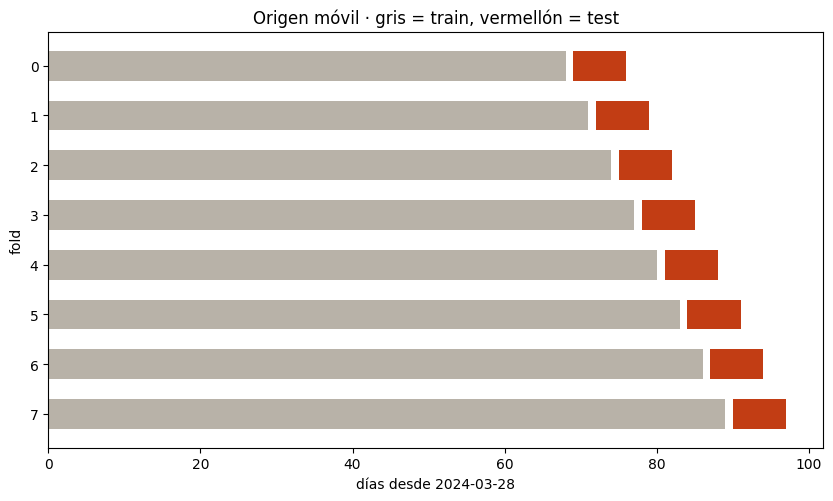

In [16]:
import matplotlib.pyplot as plt

fig, eje = plt.subplots(figsize=(10, 0.55 * len(folds) + 1))
for f in folds:
    inicio = panel[S.DATE].min()
    eje.barh(f.index, (f.origin - inicio).days, left=0, color="#B8B2A8", height=0.6)
    eje.barh(
        f.index,
        (f.test_end - f.test_start).days + 1,
        left=(f.test_start - inicio).days,
        color="#C23D14",
        height=0.6,
    )
eje.set_yticks([f.index for f in folds])
eje.set_xlabel(f"días desde {panel[S.DATE].min().date()}")
eje.set_ylabel("fold")
eje.set_title("Origen móvil · gris = train, vermellón = test")
eje.invert_yaxis()
plt.show()

## 5 · Los tres defectos reales que este andamiaje encontró

No son hipotéticos. Los tres estaban en este código.

**1 · `is_censored` del día objetivo entraba como feature.** El `merge` con la verdad
desambiguaba el choque de nombres con el sufijo `_target`, y aparecía un `is_censored_target`
que sí era del día a pronosticar. Como no figuraba en `NON_FEATURES`, entraba a la matriz. Es
predecir demanda sabiendo si va a haber quiebre: la peor clase de fuga. Lo agarró el item 1, y
es la fuga que se inyecta arriba en su caso negativo.

**2 · `days_since_start` se anclaba al mínimo de cada DataFrame.** Valía 0..18 en entrenamiento
y 0..6 en inferencia, o sea que la misma fecha recibía valores distintos según el frame. Ridge
daba MASE 3,75 con desvío 5,26; con el ancla fija da 0,91. **LightGBM apenas se movía**, que es
lo que hacía al bug difícil de ver: el modelo principal lo absorbía. Detalle en D12.

**3 · Las tres covariables conocidas de antemano llegaban en NaN a la API.** Este no lo agarró
ningún assert, y vale entender por qué: los ocho items cubren el camino de **validación**, y
este defecto vivía solo en **inferencia**. El arnés de backtesting poblaba esas columnas desde
el panel; la API no podía, porque su horizonte empieza después del último día disponible.

Medido sobre un fold real: las tres en NaN dan **MASE 1,6392** contra 0,8790 con las
covariables reales. Peor que el naive estacional, que da 1,10. Y contestaba 200 sin una
advertencia, porque LightGBM trata el NaN como una rama más. Detalle en D19.

In [17]:
# El defecto 3, reproducido: cuántas features quedan nulas si el futuro no las trae.
futuro_sin_plan = te[[S.SERIES_ID, S.DATE, fb.H]].copy()
faltantes = [c for c in S.KNOWN_FUTURE_COLS if c not in futuro_sin_plan.columns]
print(f"de las {len(features)} features del modelo, quedarían nulas: {len(faltantes)}")
print(f"y son exactamente: {faltantes}")
print("\nHay ahora un test que falla si cualquiera de las tres vuelve a llegar nula,")
print("y la API declara en la respuesta qué plan comercial asumió.")

de las 73 features del modelo, quedarían nulas: 3
y son exactamente: ['discount', 'holiday_flag', 'activity_flag']

Hay ahora un test que falla si cualquiera de las tres vuelve a llegar nula,
y la API declara en la respuesta qué plan comercial asumió.


## Lo que sale de acá

- El estado de origen hace que la fuga sea **inexpresable**, no evitada por disciplina.
- Los ocho asserts pasan sobre los datos reales **y** detectan la fuga cuando se inyecta.
- El test de shuffle y el de alineación son los dos que prueban algo en vez de afirmarlo.
- Los asserts cubren validación. El tercer defecto real vivía en inferencia, y eso es una
  limitación del checklist que conviene decir en voz alta.

Correr esto como suite: `make test-leakage`.

**Sigue:** `03_modelos_backtest.ipynb` — el backtest de origen móvil y la tabla de MASE.